# 03 Local Autoencoder

Local autoencoder anomaly detection model for wind SCADA data.

This notebook:
- trains an autoencoder using normal wind SCADA operating data
- evaluates anomaly detection performance on unseen events
- compares multiple network architectures
- saves the best-performing model, evaluation metrics, and visual results

In [1]:
import os
import json
import time
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

from tensorflow.keras import layers, regularizers, callbacks, Sequential

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"

for folder in [RAW_DIR, PROCESSED_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook:", "03_local_autoencoder.ipynb")

Project root: C:\Users\MOINODHEEN\Moinu\Aegis_Project
Notebook: 03_local_autoencoder.ipynb


In [2]:
data_path = PROCESSED_DIR / "02_baseline_combined_dataset.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Missing file: {data_path}")

df = pd.read_csv(data_path)

feature_cols = [c for c in df.columns if c.startswith("feature_")]
required_cols = {"label", "source_event"}

missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if len(feature_cols) == 0:
    raise ValueError("No feature_ columns found in processed dataset.")

print("Dataset shape:", df.shape)
print("Feature count:", len(feature_cols))
print("Label counts:\n", df["label"].value_counts().sort_index())
print("Source event counts:\n", df["source_event"].value_counts().sort_index())

dataset_summary = pd.DataFrame([{
    "rows": int(df.shape[0]),
    "feature_count": int(len(feature_cols)),
    "normal_count": int((df["label"] == 0).sum()),
    "anomaly_count": int((df["label"] == 1).sum())
}])

display(df.head())
display(dataset_summary)

dataset_summary.to_csv(RESULTS_DIR / "03_dataset_summary.csv", index=False)
dataset_summary.to_csv(TABLES_DIR / "03_dataset_summary.csv", index=False)

Dataset shape: (216919, 83)
Feature count: 81
Label counts:
 label
0    109525
1    107394
Name: count, dtype: int64
Source event counts:
 source_event
22    53036
25    54712
68    54358
69    54813
Name: count, dtype: int64


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_073,feature_074,feature_075,feature_076,feature_077,feature_078,feature_079,feature_080,label,source_event
0,16.0,74.7,175.9,1.5,1.5,7.8,0.4,0.8,24.0,24.1,...,0.0,-697.0,-146.0,0.0,0.0,0.0,0.0,19.0,0,25
1,30.0,305.1,-5.2,5.2,5.0,8.4,2.3,0.8,-1.3,-0.4,...,0.0,30039.0,-15387.0,11.2,12.0,10.9,0.2,32.0,1,68
2,15.0,123.2,0.7,9.7,9.8,17.1,1.9,1.5,-1.6,-0.1,...,0.0,254800.0,-33229.0,14.7,15.0,14.4,0.1,15.0,0,69
3,20.0,104.4,-6.3,9.5,9.6,17.5,2.2,1.4,-1.8,0.8,...,0.0,244048.0,-36021.0,14.7,15.1,14.2,0.1,22.0,1,22
4,22.0,292.2,-3.5,5.6,5.8,9.1,2.5,0.8,-1.6,-0.9,...,0.0,52269.0,-15862.0,11.4,11.8,10.9,0.2,29.0,1,22


,rows,feature_count,normal_count,anomaly_count
0,216919,81,109525,107394


In [3]:
X = df[feature_cols].copy()
y = df["label"].astype(int).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train_normal_raw = X_train_raw[y_train == 0].copy()

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

split_summary = pd.DataFrame([{
    "total_rows": int(len(df)),
    "train_rows": int(len(X_train_raw)),
    "test_rows": int(len(X_test_raw)),
    "train_normal_rows": int((y_train == 0).sum()),
    "train_anomaly_rows": int((y_train == 1).sum()),
    "test_normal_rows": int((y_test == 0).sum()),
    "test_anomaly_rows": int((y_test == 1).sum()),
    "input_dim": int(X_train_scaled.shape[1])
}])

display(split_summary)

with open(MODELS_DIR / "03_standard_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

split_summary.to_csv(RESULTS_DIR / "03_split_summary.csv", index=False)
split_summary.to_csv(TABLES_DIR / "03_split_summary.csv", index=False)

,total_rows,train_rows,test_rows,train_normal_rows,train_anomaly_rows,test_normal_rows,test_anomaly_rows,input_dim
0,216919,173535,43384,87620,85915,21905,21479,81


In [4]:
def build_autoencoder(input_dim, hidden_layers, bottleneck_dim, dropout_rate=0.0, l2_reg=0.0):
    model = Sequential(name=f"ae_{'_'.join(map(str, hidden_layers))}_b{bottleneck_dim}")

    model.add(layers.Input(shape=(input_dim,)))

    for i, units in enumerate(hidden_layers):
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
                name=f"encoder_{i+1}"
            )
        )
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"encoder_dropout_{i+1}"))

    model.add(
        layers.Dense(
            bottleneck_dim,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg),
            name="bottleneck"
        )
    )

    for i, units in enumerate(reversed(hidden_layers)):
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
                name=f"decoder_{i+1}"
            )
        )
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"decoder_dropout_{i+1}"))

    model.add(layers.Dense(input_dim, activation="linear", name="output"))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model


def reconstruction_errors(model, X_array):
    reconstructed = model.predict(X_array, verbose=0)
    return np.mean(np.square(X_array - reconstructed), axis=1)


def evaluate_autoencoder(model, X_train_normal, X_test, y_true, threshold_percentile=95):
    train_errors = reconstruction_errors(model, X_train_normal)
    test_errors = reconstruction_errors(model, X_test)

    threshold = float(np.percentile(train_errors, threshold_percentile))
    y_pred = (test_errors > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, test_errors)
    pr_auc = average_precision_score(y_true, test_errors)

    pr_curve = precision_recall_curve(y_true, test_errors)

    return {
        "threshold": threshold,
        "train_errors": train_errors,
        "test_errors": test_errors,
        "y_pred": y_pred,
        "confusion_matrix": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "pr_curve": pr_curve
    }

In [6]:
data_path = PROCESSED_DIR / "02_baseline_combined_dataset.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Missing file: {data_path}")

df = pd.read_csv(data_path)

feature_cols = [c for c in df.columns if c.startswith("feature_")]
required_cols = {"label", "source_event"}

missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if len(feature_cols) == 0:
    raise ValueError("No feature_ columns found in processed dataset.")

# Force numeric features
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Replace inf with NaN
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

nan_summary = df[feature_cols].isna().sum()
nan_cols = nan_summary[nan_summary > 0].sort_values(ascending=False)

print("Dataset shape:", df.shape)
print("Feature count:", len(feature_cols))
print("Label counts:\n", df["label"].value_counts().sort_index())
print("Source event counts:\n", df["source_event"].value_counts().sort_index())
print("Columns with NaN values:", len(nan_cols))

if len(nan_cols) > 0:
    display(nan_cols.head(20))

dataset_summary = pd.DataFrame([{
    "rows": int(df.shape[0]),
    "feature_count": int(len(feature_cols)),
    "normal_count": int((df["label"] == 0).sum()),
    "anomaly_count": int((df["label"] == 1).sum()),
    "columns_with_nan": int(len(nan_cols)),
    "total_nan_values": int(df[feature_cols].isna().sum().sum())
}])

display(df.head())
display(dataset_summary)

dataset_summary.to_csv(RESULTS_DIR / "03_dataset_summary.csv", index=False)
dataset_summary.to_csv(TABLES_DIR / "03_dataset_summary.csv", index=False)

Dataset shape: (216919, 83)
Feature count: 81
Label counts:
 label
0    109525
1    107394
Name: count, dtype: int64
Source event counts:
 source_event
22    53036
25    54712
68    54358
69    54813
Name: count, dtype: int64
Columns with NaN values: 2


feature_020    2
feature_031    2
dtype: int64

,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_073,feature_074,feature_075,feature_076,feature_077,feature_078,feature_079,feature_080,label,source_event
0,16.0,74.7,175.9,1.5,1.5,7.8,0.4,0.8,24.0,24.1,...,0.0,-697.0,-146.0,0.0,0.0,0.0,0.0,19.0,0,25
1,30.0,305.1,-5.2,5.2,5.0,8.4,2.3,0.8,-1.3,-0.4,...,0.0,30039.0,-15387.0,11.2,12.0,10.9,0.2,32.0,1,68
2,15.0,123.2,0.7,9.7,9.8,17.1,1.9,1.5,-1.6,-0.1,...,0.0,254800.0,-33229.0,14.7,15.0,14.4,0.1,15.0,0,69
3,20.0,104.4,-6.3,9.5,9.6,17.5,2.2,1.4,-1.8,0.8,...,0.0,244048.0,-36021.0,14.7,15.1,14.2,0.1,22.0,1,22
4,22.0,292.2,-3.5,5.6,5.8,9.1,2.5,0.8,-1.6,-0.9,...,0.0,52269.0,-15862.0,11.4,11.8,10.9,0.2,29.0,1,22


,rows,feature_count,normal_count,anomaly_count,columns_with_nan,total_nan_values
0,216919,81,109525,107394,2,4


In [7]:
X = df[feature_cols].copy()
y = df["label"].astype(int).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train_normal_raw = X_train_raw[y_train == 0].copy()

# Fill NaN using training-normal medians only
train_normal_medians = X_train_normal_raw.median()

X_train_raw = X_train_raw.fillna(train_normal_medians)
X_test_raw = X_test_raw.fillna(train_normal_medians)
X_train_normal_raw = X_train_normal_raw.fillna(train_normal_medians)

# Final safety checks before scaling
for name, arr_df in {
    "X_train_raw": X_train_raw,
    "X_test_raw": X_test_raw,
    "X_train_normal_raw": X_train_normal_raw
}.items():
    if not np.isfinite(arr_df.to_numpy()).all():
        raise ValueError(f"{name} still contains non-finite values before scaling.")

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Final safety checks after scaling
for name, arr in {
    "X_train_normal_scaled": X_train_normal_scaled,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled
}.items():
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains non-finite values after scaling.")

split_summary = pd.DataFrame([{
    "total_rows": int(len(df)),
    "train_rows": int(len(X_train_raw)),
    "test_rows": int(len(X_test_raw)),
    "train_normal_rows": int((y_train == 0).sum()),
    "train_anomaly_rows": int((y_train == 1).sum()),
    "test_normal_rows": int((y_test == 0).sum()),
    "test_anomaly_rows": int((y_test == 1).sum()),
    "input_dim": int(X_train_scaled.shape[1])
}])

display(split_summary)

with open(MODELS_DIR / "03_standard_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

pd.DataFrame({
    "feature": feature_cols,
    "train_normal_median": train_normal_medians.values
}).to_csv(RESULTS_DIR / "03_train_normal_feature_medians.csv", index=False)

split_summary.to_csv(RESULTS_DIR / "03_split_summary.csv", index=False)
split_summary.to_csv(TABLES_DIR / "03_split_summary.csv", index=False)

,total_rows,train_rows,test_rows,train_normal_rows,train_anomaly_rows,test_normal_rows,test_anomaly_rows,input_dim
0,216919,173535,43384,87620,85915,21905,21479,81


In [8]:
def build_autoencoder(input_dim, hidden_layers, bottleneck_dim, dropout_rate=0.0, l2_reg=0.0):
    model = Sequential(name=f"ae_{'_'.join(map(str, hidden_layers))}_b{bottleneck_dim}")
    model.add(layers.Input(shape=(input_dim,)))

    for i, units in enumerate(hidden_layers):
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
                name=f"encoder_{i+1}"
            )
        )
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"encoder_dropout_{i+1}"))

    model.add(
        layers.Dense(
            bottleneck_dim,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg),
            name="bottleneck"
        )
    )

    for i, units in enumerate(reversed(hidden_layers)):
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
                name=f"decoder_{i+1}"
            )
        )
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"decoder_dropout_{i+1}"))

    model.add(layers.Dense(input_dim, activation="linear", name="output"))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model


def reconstruction_errors(model, X_array):
    reconstructed = model.predict(X_array, verbose=0)

    if not np.isfinite(reconstructed).all():
        raise ValueError("Model predictions contain non-finite values.")

    errs = np.mean(np.square(X_array - reconstructed), axis=1)

    if not np.isfinite(errs).all():
        raise ValueError("Reconstruction errors contain non-finite values.")

    return errs


def evaluate_autoencoder(model, X_train_normal, X_test, y_true, threshold_percentile=95):
    train_errors = reconstruction_errors(model, X_train_normal)
    test_errors = reconstruction_errors(model, X_test)

    threshold = float(np.percentile(train_errors, threshold_percentile))
    y_pred = (test_errors > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, test_errors)
    pr_auc = average_precision_score(y_true, test_errors)

    pr_curve = precision_recall_curve(y_true, test_errors)

    return {
        "threshold": threshold,
        "train_errors": train_errors,
        "test_errors": test_errors,
        "y_pred": y_pred,
        "confusion_matrix": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "pr_curve": pr_curve
    }

In [9]:
architecture_grid = [
    {"name": "shallow_b8",  "hidden_layers": [32],     "bottleneck": 8,  "dropout": 0.0, "l2": 1e-5},
    {"name": "shallow_b16", "hidden_layers": [32],     "bottleneck": 16, "dropout": 0.0, "l2": 1e-5},
    {"name": "shallow_b32", "hidden_layers": [32],     "bottleneck": 32, "dropout": 0.0, "l2": 1e-5},
    {"name": "deep_b8",     "hidden_layers": [64, 32], "bottleneck": 8,  "dropout": 0.0, "l2": 1e-5},
    {"name": "deep_b16",    "hidden_layers": [64, 32], "bottleneck": 16, "dropout": 0.0, "l2": 1e-5},
    {"name": "deep_b32",    "hidden_layers": [64, 32], "bottleneck": 32, "dropout": 0.0, "l2": 1e-5},
]

SWEEP_TRAIN_LIMIT = min(60000, len(X_train_normal_scaled))
X_sweep = X_train_normal_scaled[:SWEEP_TRAIN_LIMIT]

sweep_rows = []
best_bundle = None

for cfg in architecture_grid:
    tf.keras.backend.clear_session()
    model = build_autoencoder(
        input_dim=X_train_normal_scaled.shape[1],
        hidden_layers=cfg["hidden_layers"],
        bottleneck_dim=cfg["bottleneck"],
        dropout_rate=cfg["dropout"],
        l2_reg=cfg["l2"]
    )

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    start = time.time()
    history = model.fit(
        X_sweep, X_sweep,
        epochs=35,
        batch_size=256,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    fit_time = time.time() - start

    eval_out = evaluate_autoencoder(
        model=model,
        X_train_normal=X_sweep,
        X_test=X_test_scaled,
        y_true=y_test.values,
        threshold_percentile=95
    )

    row = {
        "model_name": cfg["name"],
        "hidden_layers": str(cfg["hidden_layers"]),
        "bottleneck": int(cfg["bottleneck"]),
        "dropout": float(cfg["dropout"]),
        "l2_reg": float(cfg["l2"]),
        "epochs_run": int(len(history.history["loss"])),
        "fit_time_seconds": round(fit_time, 4),
        "parameter_count": int(model.count_params()),
        "threshold": eval_out["threshold"],
        "precision": eval_out["precision"],
        "recall": eval_out["recall"],
        "f1": eval_out["f1"],
        "roc_auc": eval_out["roc_auc"],
        "pr_auc": eval_out["pr_auc"],
        "tn": eval_out["tn"],
        "fp": eval_out["fp"],
        "fn": eval_out["fn"],
        "tp": eval_out["tp"],
        "predicted_anomalies": int(eval_out["y_pred"].sum())
    }
    sweep_rows.append(row)

    if best_bundle is None:
        best_bundle = {"cfg": cfg, "row": row}
    else:
        current_key = (row["f1"], row["pr_auc"], row["precision"])
        best_key = (best_bundle["row"]["f1"], best_bundle["row"]["pr_auc"], best_bundle["row"]["precision"])
        if current_key > best_key:
            best_bundle = {"cfg": cfg, "row": row}

sweep_df = pd.DataFrame(sweep_rows).sort_values(
    ["f1", "pr_auc", "precision"],
    ascending=False
).reset_index(drop=True)

display(sweep_df)

sweep_df.to_csv(RESULTS_DIR / "03_autoencoder_architecture_sweep.csv", index=False)
sweep_df.to_csv(TABLES_DIR / "03_autoencoder_architecture_sweep.csv", index=False)

print("Best candidate from sweep:", best_bundle["cfg"]["name"])

,model_name,hidden_layers,bottleneck,dropout,l2_reg,epochs_run,fit_time_seconds,parameter_count,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,predicted_anomalies
0,deep_b32,"[64, 32]",32,0.0,0.00001,35,28.1986,16817,0.030770,0.855981,0.313516,0.458938,0.716173,0.730417,20772,1133,14745,6734,7867
1,shallow_b32,[32],32,0.0,0.00001,35,24.4290,7409,0.038262,0.833879,0.272499,0.410766,0.710695,0.717146,20739,1166,15626,5853,7019
2,deep_b8,"[64, 32]",8,0.0,0.00001,35,28.1281,15257,0.095005,0.829402,0.253736,0.388592,0.700337,0.710798,20784,1121,16029,5450,6571
3,shallow_b8,[32],8,0.0,0.00001,35,24.4136,5849,0.134163,0.819133,0.229620,0.358691,0.695558,0.684399,20816,1089,16547,4932,6021
4,deep_b16,"[64, 32]",16,0.0,0.00001,35,31.2863,15777,0.050516,0.809765,0.223148,0.349880,0.707641,0.705277,20779,1126,16686,4793,5919
5,shallow_b16,[32],16,0.0,0.00001,35,24.7499,6369,0.067423,0.789031,0.192234,0.309149,0.695051,0.684106,20801,1104,17350,4129,5233


Best candidate from sweep: deep_b32


In [10]:
best_cfg = best_bundle["cfg"]

tf.keras.backend.clear_session()
best_model = build_autoencoder(
    input_dim=X_train_normal_scaled.shape[1],
    hidden_layers=best_cfg["hidden_layers"],
    bottleneck_dim=best_cfg["bottleneck"],
    dropout_rate=best_cfg["dropout"],
    l2_reg=best_cfg["l2"]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

start = time.time()
best_history = best_model.fit(
    X_train_normal_scaled, X_train_normal_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
best_fit_time = time.time() - start

final_eval = evaluate_autoencoder(
    model=best_model,
    X_train_normal=X_train_normal_scaled,
    X_test=X_test_scaled,
    y_true=y_test.values,
    threshold_percentile=95
)

final_metrics = pd.DataFrame([{
    "model_name": best_cfg["name"],
    "hidden_layers": str(best_cfg["hidden_layers"]),
    "bottleneck": int(best_cfg["bottleneck"]),
    "dropout": float(best_cfg["dropout"]),
    "l2_reg": float(best_cfg["l2"]),
    "fit_time_seconds": round(best_fit_time, 4),
    "epochs_run": int(len(best_history.history["loss"])),
    "parameter_count": int(best_model.count_params()),
    "threshold": final_eval["threshold"],
    "precision": final_eval["precision"],
    "recall": final_eval["recall"],
    "f1": final_eval["f1"],
    "roc_auc": final_eval["roc_auc"],
    "pr_auc": final_eval["pr_auc"],
    "tn": final_eval["tn"],
    "fp": final_eval["fp"],
    "fn": final_eval["fn"],
    "tp": final_eval["tp"],
    "predicted_anomalies": int(final_eval["y_pred"].sum()),
    "train_normal_rows": int(len(X_train_normal_scaled)),
    "test_rows": int(len(X_test_scaled)),
    "input_dim": int(X_test_scaled.shape[1])
}])

display(final_metrics)

final_metrics.to_csv(RESULTS_DIR / "03_local_autoencoder_metrics.csv", index=False)
final_metrics.to_csv(TABLES_DIR / "03_local_autoencoder_metrics.csv", index=False)

best_model.save(MODELS_DIR / "03_best_autoencoder.keras")

with open(RESULTS_DIR / "03_local_autoencoder_metrics.json", "w") as f:
    json.dump(final_metrics.iloc[0].to_dict(), f, indent=2)

pd.DataFrame({"train_error": final_eval["train_errors"]}).to_csv(
    RESULTS_DIR / "03_train_normal_reconstruction_errors.csv", index=False
)
pd.DataFrame({
    "test_error": final_eval["test_errors"],
    "true_label": y_test.values,
    "pred_label": final_eval["y_pred"]
}).to_csv(
    RESULTS_DIR / "03_test_reconstruction_errors.csv", index=False
)

,model_name,hidden_layers,bottleneck,dropout,l2_reg,fit_time_seconds,epochs_run,parameter_count,threshold,precision,...,roc_auc,pr_auc,tn,fp,fn,tp,predicted_anomalies,train_normal_rows,test_rows,input_dim
0,deep_b32,"[64, 32]",32,0.0,0.00001,55.6151,50,16817,0.021928,0.883965,...,0.723272,0.750066,20787,1118,12962,8517,9635,87620,43384,81


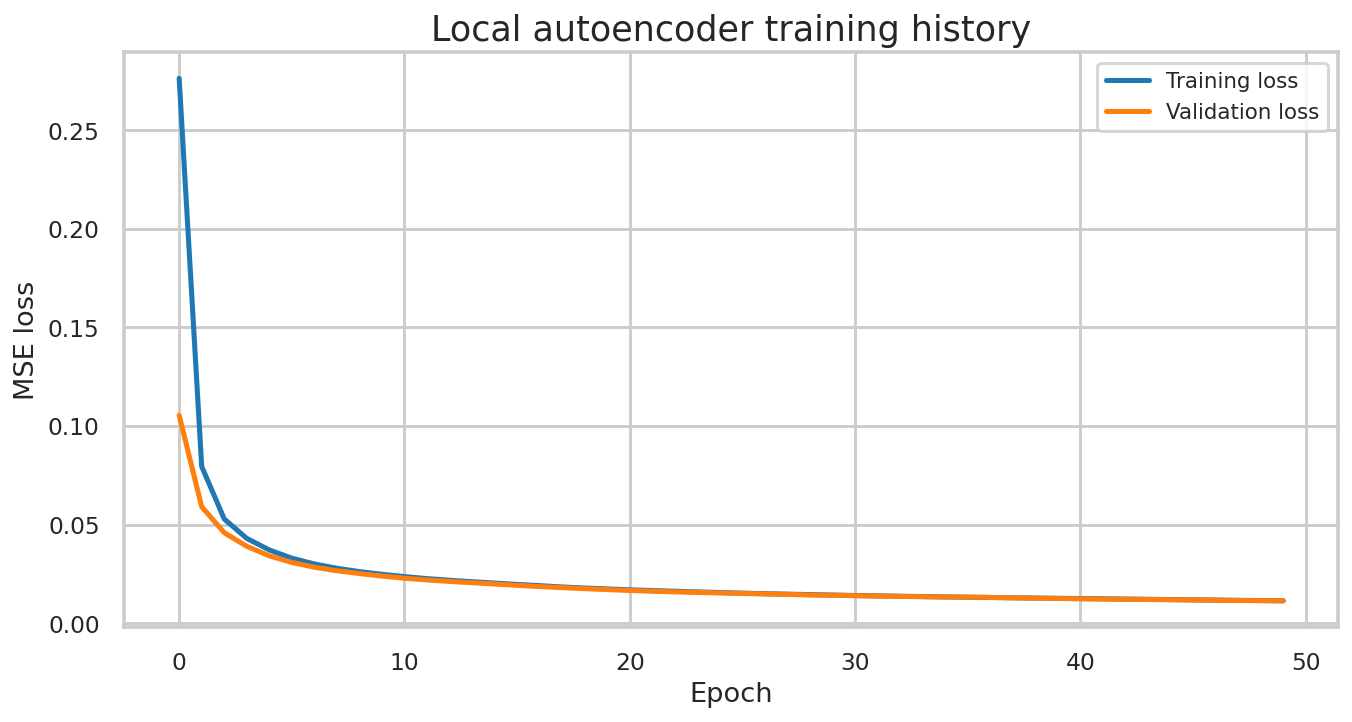

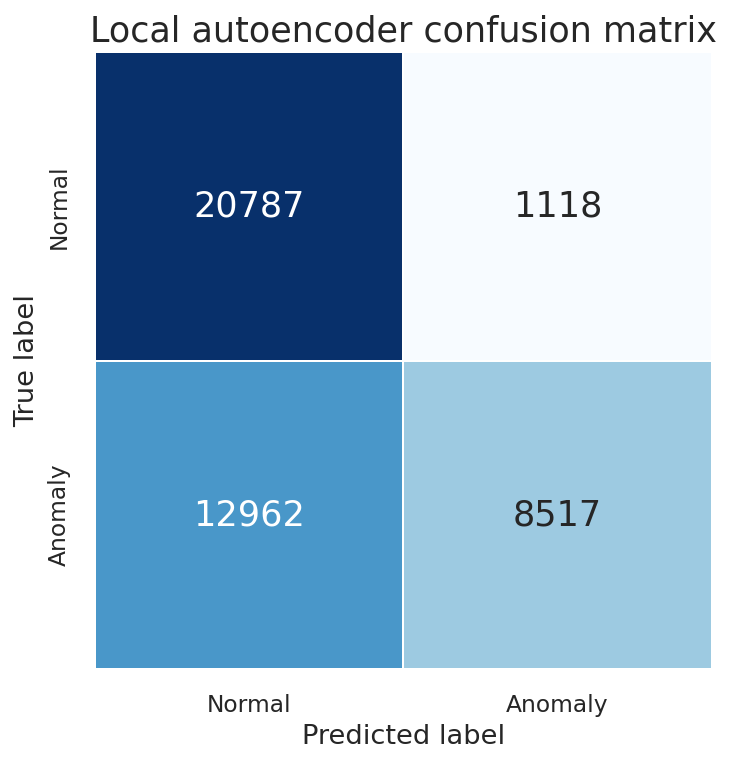

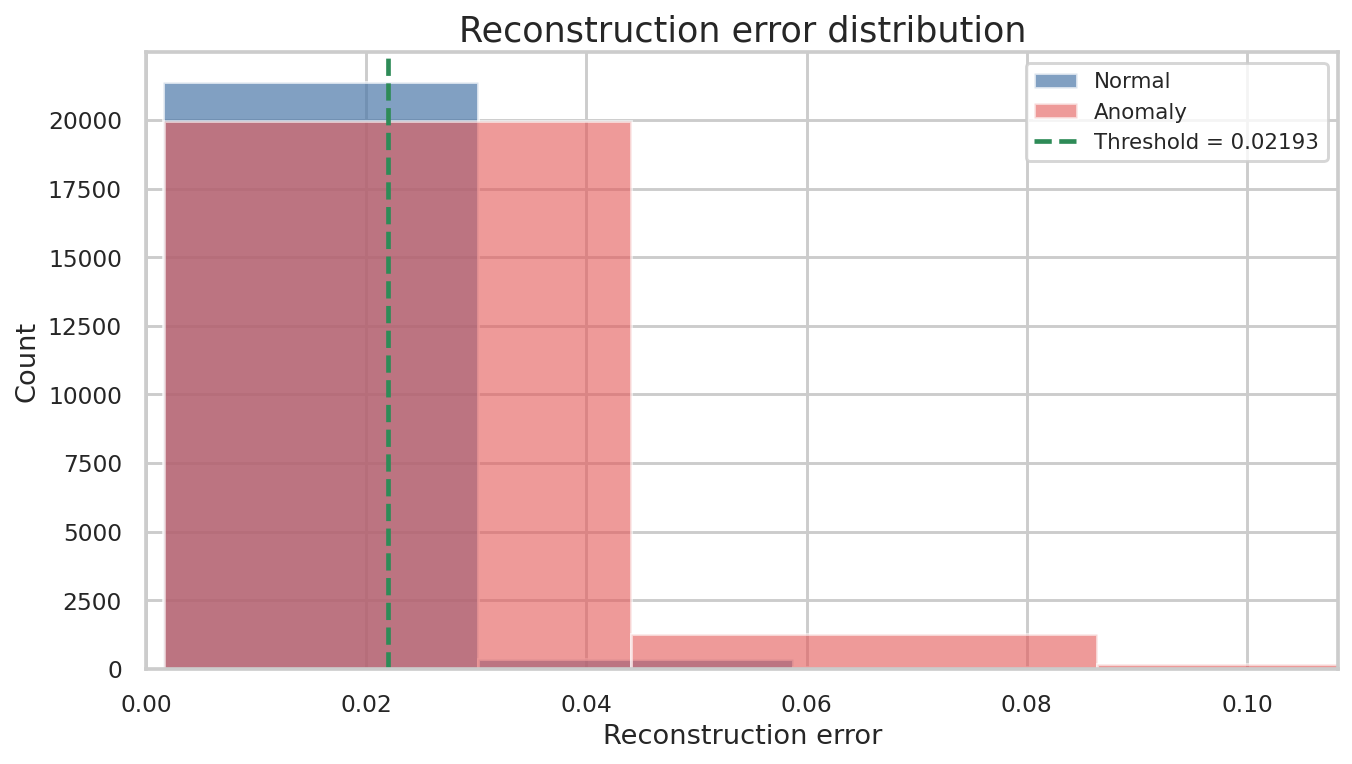

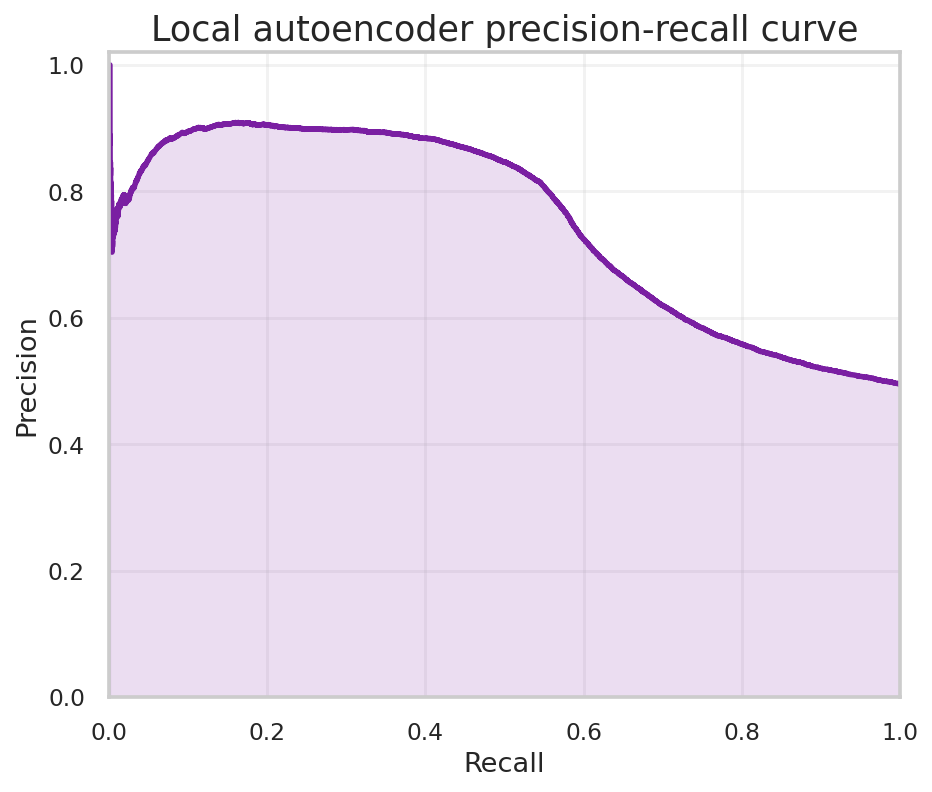

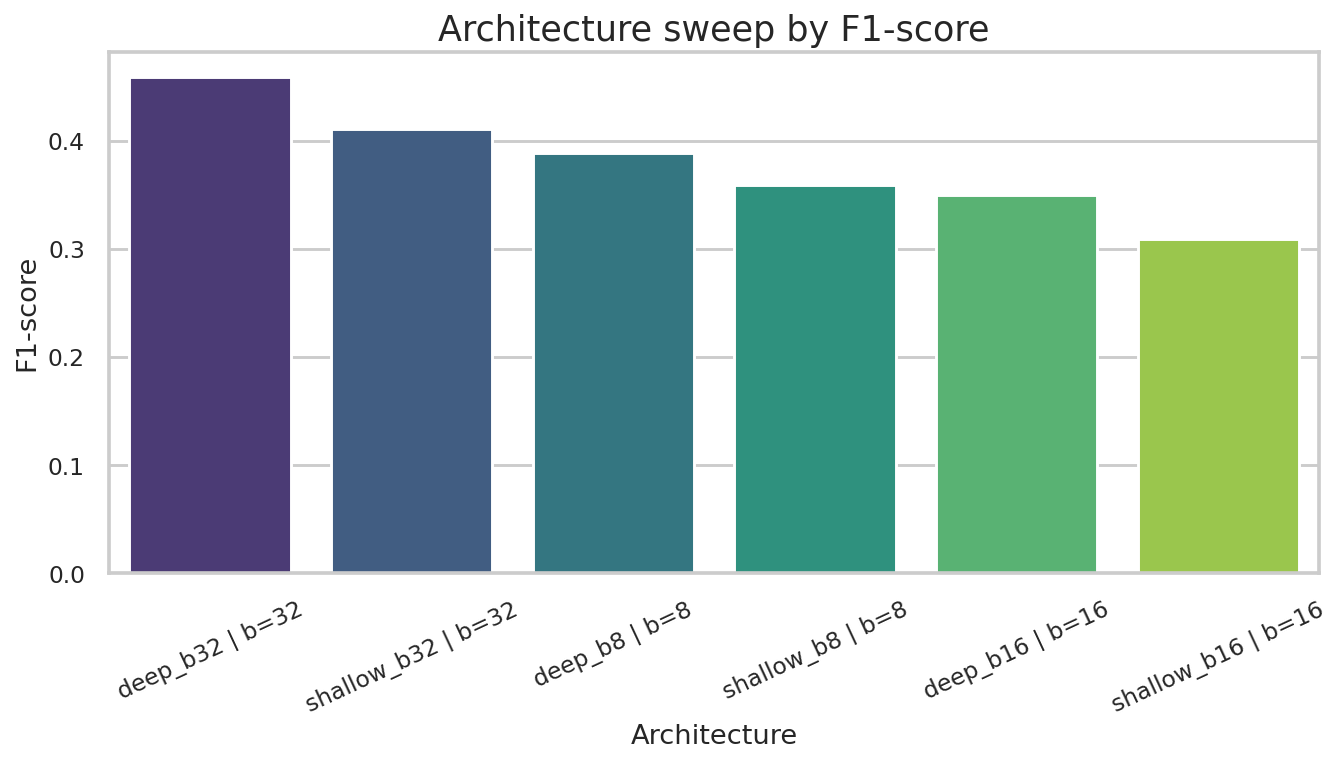

In [18]:
import matplotlib as mpl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "font.family": "DejaVu Sans"
})

cm = final_eval["confusion_matrix"]
pr_precision, pr_recall, pr_thresholds = final_eval["pr_curve"]

train_err = np.asarray(final_eval["train_errors"])
test_err = np.asarray(final_eval["test_errors"])
y_true = np.asarray(y_test.values)

normal_err = test_err[y_true == 0]
anomaly_err = test_err[y_true == 1]

# Use a clipped upper limit for the main histogram view
hist_upper = np.percentile(test_err, 99.5)

# 1. Training history
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(best_history.history["loss"], label="Training loss", linewidth=2.6, color="#1f77b4")
ax.plot(best_history.history["val_loss"], label="Validation loss", linewidth=2.6, color="#ff7f0e")
ax.set_title("Local autoencoder training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_local_autoencoder_training_history.png", bbox_inches="tight")
plt.show()

# 2. Confusion matrix
fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="white",
    square=True,
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
    ax=ax
)
ax.set_title("Local autoencoder confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_local_autoencoder_confusion_matrix.png", bbox_inches="tight")
plt.show()

# 3. Reconstruction error distribution - zoomed for readability
fig, ax = plt.subplots(figsize=(10, 5.8))
bins = 70
ax.hist(normal_err, bins=bins, alpha=0.70, label="Normal", color="#4C78A8", edgecolor="white")
ax.hist(anomaly_err, bins=bins, alpha=0.60, label="Anomaly", color="#E45756", edgecolor="white")
ax.axvline(final_eval["threshold"], color="#2E8B57", linestyle="--", linewidth=2.4,
           label=f"Threshold = {final_eval['threshold']:.5f}")
ax.set_xlim(0, hist_upper)
ax.set_title("Reconstruction error distribution")
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("Count")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_local_autoencoder_error_hist.png", bbox_inches="tight")
plt.show()

# 4. Precision-recall curve
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pr_recall, pr_precision, linewidth=2.8, color="#7A1FA2")
ax.fill_between(pr_recall, pr_precision, alpha=0.15, color="#7A1FA2")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title("Local autoencoder precision-recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_local_autoencoder_pr_curve.png", bbox_inches="tight")
plt.show()

# 5. Architecture sweep summary figure
plot_df = sweep_df.copy()
plot_df["label"] = plot_df["model_name"] + " | b=" + plot_df["bottleneck"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.barplot(
    data=plot_df,
    x="label",
    y="f1",
    hue="label",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)
ax.set_title("Architecture sweep by F1-score")
ax.set_xlabel("Architecture")
ax.set_ylabel("F1-score")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_autoencoder_architecture_sweep.png", bbox_inches="tight")
plt.show()

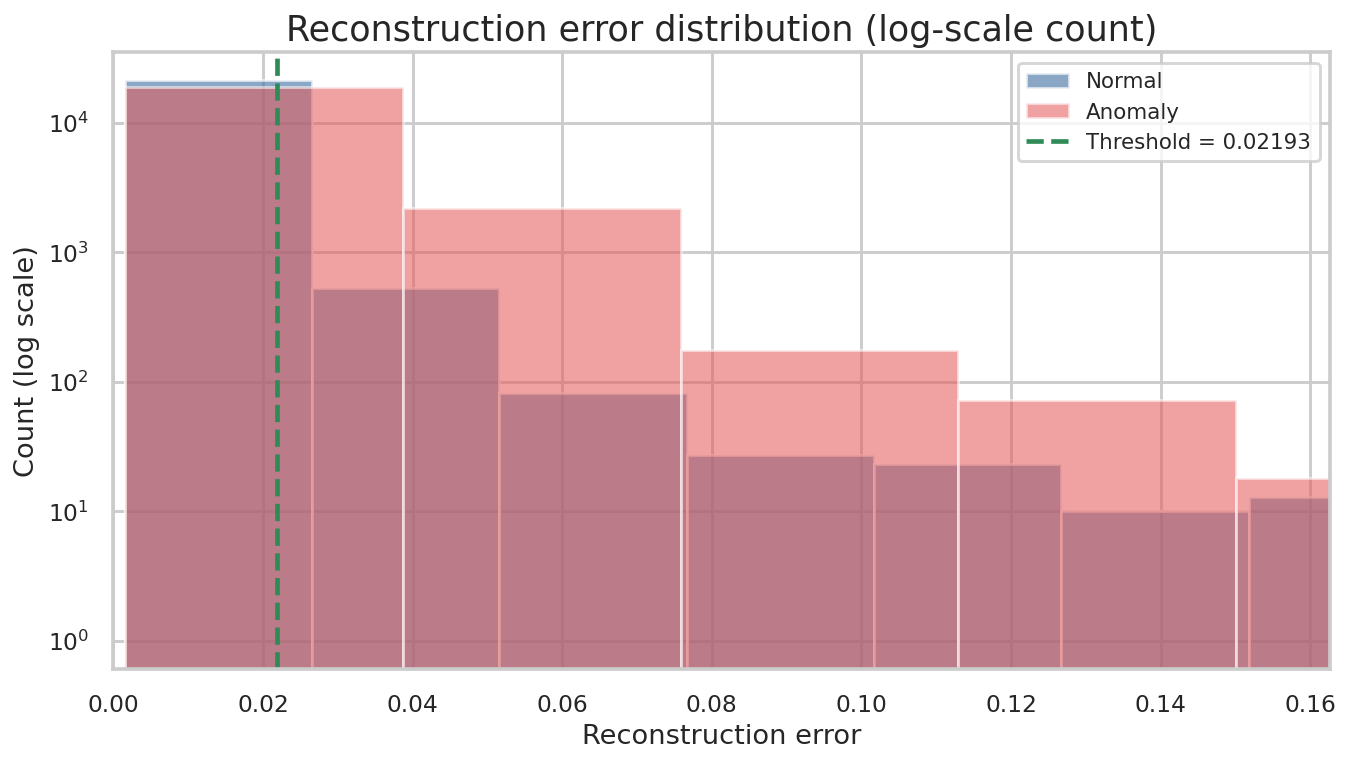

In [16]:
# Optional: log-scale histogram for appendix / analysis
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.hist(normal_err, bins=80, alpha=0.65, label="Normal", color="#4C78A8", edgecolor="white")
ax.hist(anomaly_err, bins=80, alpha=0.55, label="Anomaly", color="#E45756", edgecolor="white")
ax.axvline(final_eval["threshold"], color="#2E8B57", linestyle="--", linewidth=2.4,
           label=f"Threshold = {final_eval['threshold']:.5f}")
ax.set_yscale("log")
ax.set_xlim(0, np.percentile(test_err, 99.8))
ax.set_title("Reconstruction error distribution (log-scale count)")
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("Count (log scale)")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_local_autoencoder_error_hist_log.png", bbox_inches="tight")
plt.show()

In [17]:
artifact_summary = {
    "notebook": "03_local_autoencoder.ipynb",
    "artifacts_created": [
        "models\\03_best_autoencoder.keras",
        "models\\03_standard_scaler.pkl",
        "results\\03_autoencoder_architecture_sweep.csv",
        "results\\03_dataset_summary.csv",
        "results\\03_local_autoencoder_metrics.csv",
        "results\\03_local_autoencoder_metrics.json",
        "results\\03_split_summary.csv",
        "results\\03_test_reconstruction_errors.csv",
        "results\\03_train_normal_reconstruction_errors.csv",
        "tables\\03_autoencoder_architecture_sweep.csv",
        "tables\\03_dataset_summary.csv",
        "tables\\03_local_autoencoder_metrics.csv",
        "tables\\03_split_summary.csv",
        "figures\\03_local_autoencoder_confusion_matrix.png",
        "figures\\03_local_autoencoder_error_hist.png",
        "figures\\03_local_autoencoder_pr_curve.png",
        "figures\\03_local_autoencoder_training_history.png"
    ],
    "best_model_name": best_cfg["name"],
    "best_f1": float(final_metrics.iloc[0]["f1"]),
    "timestamp": pd.Timestamp.now().isoformat()
}

with open(RESULTS_DIR / "03_artifact_summary.json", "w") as f:
    json.dump(artifact_summary, f, indent=2)

artifact_summary

{'notebook': '03_local_autoencoder.ipynb',
 'artifacts_created': ['models\\03_best_autoencoder.keras',
  'models\\03_standard_scaler.pkl',
  'results\\03_autoencoder_architecture_sweep.csv',
  'results\\03_dataset_summary.csv',
  'results\\03_local_autoencoder_metrics.csv',
  'results\\03_local_autoencoder_metrics.json',
  'results\\03_split_summary.csv',
  'results\\03_test_reconstruction_errors.csv',
  'results\\03_train_normal_reconstruction_errors.csv',
  'tables\\03_autoencoder_architecture_sweep.csv',
  'tables\\03_dataset_summary.csv',
  'tables\\03_local_autoencoder_metrics.csv',
  'tables\\03_split_summary.csv',
  'figures\\03_local_autoencoder_confusion_matrix.png',
  'figures\\03_local_autoencoder_error_hist.png',
  'figures\\03_local_autoencoder_pr_curve.png',
  'figures\\03_local_autoencoder_training_history.png'],
 'best_model_name': 'deep_b32',
 'best_f1': 0.5474705920164556,
 'timestamp': '2026-04-02T23:07:46.976619'}